# Classificação de Churn com Regressão Logística

```
# O que é Churn?
Churn é uma métrica que indica a percentagem de clientes que deixam de fazer negócios com uma empresa num determinado período.
```

O dataset utilizado é proveniente de uma empresa fictícia de telefonia, criado e disponibilizado pela IBM para fins didáticos.

O dicionário com as descrições das features pode ser encontrado [neste link no Kaggle](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset).

# 🧩 Libraries

In [30]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn import metrics
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_auc_score, roc_curve
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 🗂️ Data


In [31]:
df_mi = pd.read_csv('/content/churn_df.csv', index_col=0)
display(df_mi)

,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
CustomerID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,33.964131,-118.272783,1,0,0,0,2,1,0,0,...,0,0,0,0,1,3,53.85,108.15,1,3239
9237-HQITU,34.059281,-118.307420,0,0,0,1,2,1,0,1,...,0,0,0,0,1,2,70.70,151.65,1,2701
9305-CDSKC,34.048013,-118.293953,0,0,0,1,8,1,2,1,...,0,2,2,0,1,2,99.65,820.50,1,5372
7892-POOKP,34.062125,-118.315709,0,0,1,1,28,1,2,1,...,2,2,2,0,1,2,104.80,3046.05,1,5003
0280-XJGEX,34.039224,-118.266293,1,0,0,1,49,1,2,1,...,0,2,2,0,1,0,103.70,5036.30,1,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2569-WGERO,34.341737,-116.539416,0,0,0,0,72,1,0,2,...,1,1,1,2,1,0,21.15,1419.40,0,5306
6840-RESVB,34.667815,-117.536183,1,0,1,1,24,1,2,0,...,2,2,2,1,1,3,84.80,1990.50,0,2140
2234-XADUH,34.559882,-115.637164,0,0,1,1,72,1,2,1,...,0,2,2,1,1,1,103.20,7362.90,0,5560


# 🤖 Model Building

In [32]:
df_features = df_mi.drop(columns=['Churn Value'])
target = df_mi['Churn Value']

In [33]:
df_features.head()

,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
CustomerID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,33.964131,-118.272783,1,0,0,0,2,1,0,0,...,0,0,0,0,0,1,3,53.85,108.15,3239
9237-HQITU,34.059281,-118.307420,0,0,0,1,2,1,0,1,...,0,0,0,0,0,1,2,70.70,151.65,2701
9305-CDSKC,34.048013,-118.293953,0,0,0,1,8,1,2,1,...,2,0,2,2,0,1,2,99.65,820.50,5372
7892-POOKP,34.062125,-118.315709,0,0,1,1,28,1,2,1,...,2,2,2,2,0,1,2,104.80,3046.05,5003
0280-XJGEX,34.039224,-118.266293,1,0,0,1,49,1,2,1,...,2,0,2,2,0,1,0,103.70,5036.30,5340


### Mutual Information

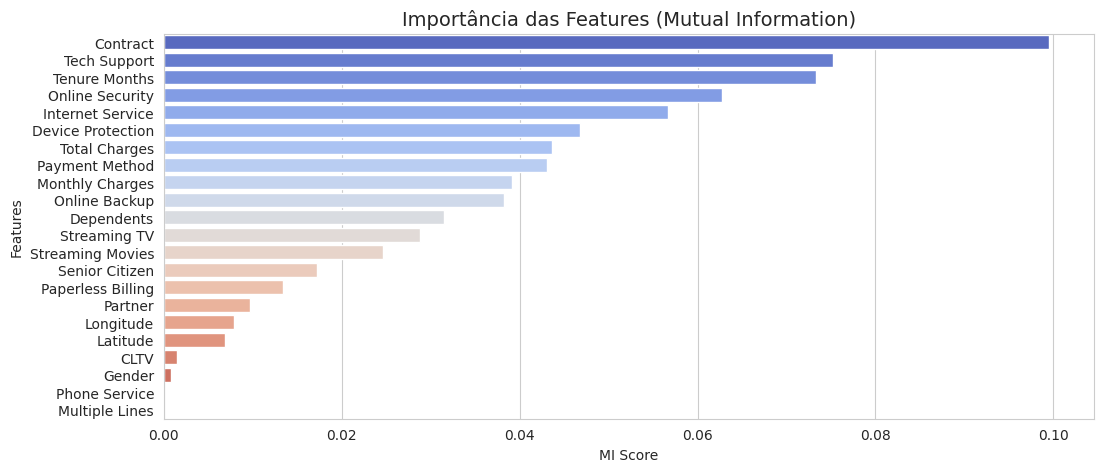

In [34]:
mi_scores = mutual_info_classif(df_features, target, discrete_features='auto') # medindo a dependência entre cada feature e o target.
mi_scores = pd.Series(mi_scores, index=df_features.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")
sns.barplot(x=mi_scores.values, y=mi_scores.index, palette="coolwarm", hue=mi_scores.index, legend=False)
plt.title("Importância das Features (Mutual Information)", fontsize=14)
plt.xlabel("MI Score")
plt.ylabel("Features")
plt.show()

In [35]:
selected_features = mi_scores[mi_scores > 0.02].index
df_features = df_features[selected_features]
df_features.head()

,Contract,Tech Support,Tenure Months,Online Security,Internet Service,Device Protection,Total Charges,Payment Method,Monthly Charges,Online Backup,Dependents,Streaming TV,Streaming Movies
CustomerID,,,,,,,,,,,,,
3668-QPYBK,0,0,2,2,0,0,108.15,3,53.85,2,0,0,0
9237-HQITU,0,0,2,0,1,0,151.65,2,70.70,0,1,0,0
9305-CDSKC,0,0,8,0,1,2,820.50,2,99.65,0,1,2,2
7892-POOKP,0,2,28,0,1,2,3046.05,2,104.80,0,1,2,2
0280-XJGEX,0,0,49,0,1,2,5036.30,0,103.70,2,1,2,2


## Correlation matrix


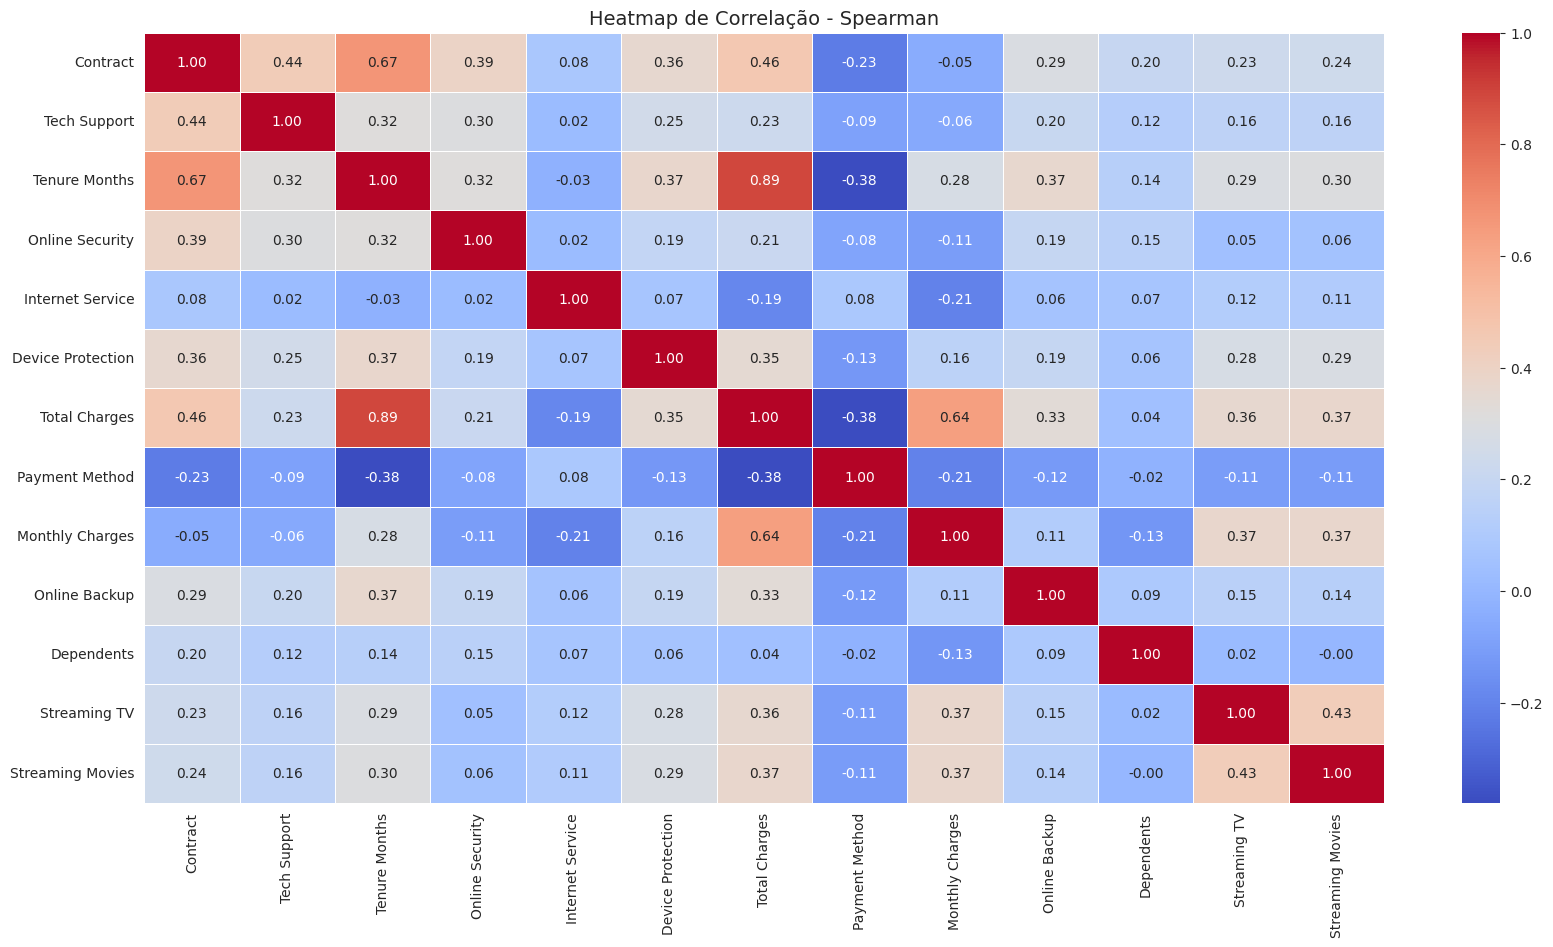

In [36]:
# Para evitar multicolinearidade, verificando colunas da matriz X (df_features) são linearmente independentes.
plt.figure(figsize = (20,10))
correlation = df_features.corr(method='spearman')
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap de Correlação - Spearman", fontsize=14)
plt.show()

Pelo mapa de correlação, percebemos que:

> Tenure Months e Total Charges = 0.89


Para evitar a instabilidade dos coeficientes e a dificuldade de interpretação, vamos excluí-las do nosso modelo, evitando assim a multicolinearidade.

In [37]:
df_features.drop(columns=['Total Charges'], inplace=True)

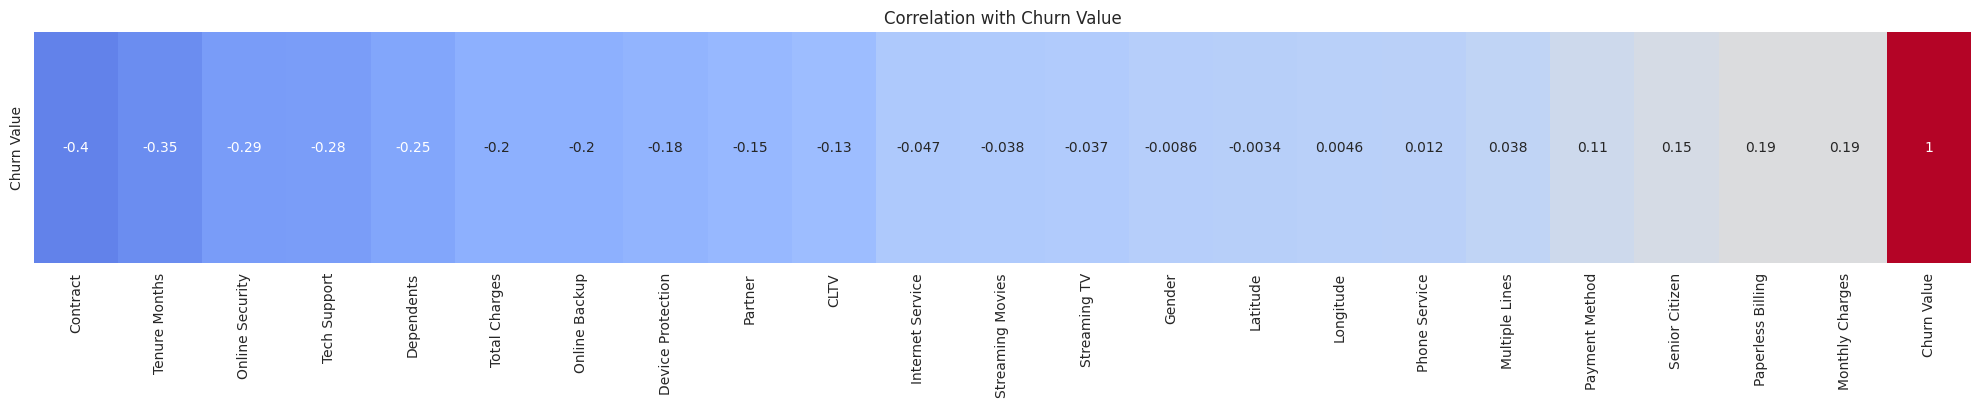

In [38]:
corr_matrix = df_mi.corr()

# Extract the row corresponding to 'Target_Column'
target_corr = corr_matrix.loc[['Churn Value']]
sorted_columns = target_corr.columns[target_corr.values.argsort()[0]]
target_corr = target_corr[sorted_columns]


plt.figure(figsize=(25, 3))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', cbar=False,  vmin=-.6, vmax=1)
plt.title("Correlation with Churn Value")
plt.show()

Vamos analisar as outras variavéis pelo cálculo dos autovalores da matriz de covariância. <br><br>
Os que tiverem valor muito baixo indicam redundância na informação trazida pela respectiva variável e, consequentemente, que existe multicolinearidade;
Fator de Inflação da Variância (VIF):

> Multicolinearidade Baixa ⇔ 0 < VIF < 5 <br>
Multicolinearidade Moderada ⇔ 5 ≤ VIF < 10 <br>
Multicolinearidade Alta ⇔ VIF ≥ 10

In [39]:
# Calcula o VIF para cada variável independente
vif_data = pd.DataFrame()
vif_data["Variável"] = df_features.columns
vif_data["VIF"] = [variance_inflation_factor(df_features.values, i) for i in range(df_features.shape[1])]

vif_data

,Variável,VIF
0,Contract,4.025733
1,Tech Support,2.341157
2,Tenure Months,6.722929
3,Online Security,2.207297
4,Internet Service,2.343935
5,Device Protection,2.610601
6,Payment Method,2.631087
7,Monthly Charges,5.633220
8,Online Backup,2.434220
9,Dependents,1.366718


In [40]:
df_features.head()

,Contract,Tech Support,Tenure Months,Online Security,Internet Service,Device Protection,Payment Method,Monthly Charges,Online Backup,Dependents,Streaming TV,Streaming Movies
CustomerID,,,,,,,,,,,,
3668-QPYBK,0,0,2,2,0,0,3,53.85,2,0,0,0
9237-HQITU,0,0,2,0,1,0,2,70.70,0,1,0,0
9305-CDSKC,0,0,8,0,1,2,2,99.65,0,1,2,2
7892-POOKP,0,2,28,0,1,2,2,104.80,0,1,2,2
0280-XJGEX,0,0,49,0,1,2,0,103.70,2,1,2,2


In [41]:
target.head()

,Churn Value
CustomerID,
3668-QPYBK,1
9237-HQITU,1
9305-CDSKC,1
7892-POOKP,1
0280-XJGEX,1


## Train & Test

In [42]:
# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(df_features, target, train_size=0.7, test_size=0.2, random_state=42)

In [43]:
print(f"X_train: {X_train.shape[0]}")
print(f"X_test: {X_test.shape[0]}")

X_train: 4930
X_test: 1409


In [44]:
# Treinando o modelo
log_reg = LogisticRegression(max_iter=1000, random_state=42)
res = log_reg.fit(X_train, y_train.values.ravel())
log_reg.fit(X_train, y_train.values.ravel())

LogisticRegression(max_iter=1000, random_state=42)

# 🚩 Test results

In [45]:
# Fazendo a predição no conjunto de teste
y_test_pred = log_reg.predict_proba(X_test)[:, 1]

result_test = pd.DataFrame({'Churn': y_test.values, 'Churn_Prob': y_test_pred})
result_test['CustomerID'] = y_test.index
result_test['Predicted'] = result_test.Churn_Prob.map(lambda x: 1 if x > 0.5 else 0)

result_test.head()

,Churn,Churn_Prob,CustomerID,Predicted
0,1,0.594842,2189-WWOEW,1
1,0,0.403024,2446-ZKVAF,0
2,0,0.252032,4986-MXSFP,0
3,1,0.669878,5868-YWPDW,1
4,1,0.470684,9412-GHEEC,0


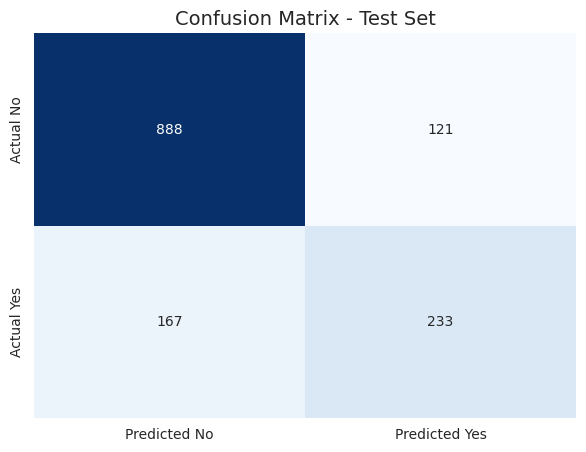

In [46]:
# Calculando a matriz de confusão para o conjunto de teste
cm_test = confusion_matrix(result_test.Churn, result_test.Predicted)

plt.figure(figsize=(7,5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted No", "Predicted Yes"], yticklabels=["Actual No", "Actual Yes"], cbar=False)
plt.title('Confusion Matrix - Test Set', fontsize=14)
plt.show()

**Classe 0** (negativo): previu corretamente em 890 casos
                    previu incorretamente em 174 casos


**Classe 1** (positivo): previu corretamente 226 casos
                    previu incorretamente em 119 casos

In [47]:
# Acurácia no conjunto de teste
accuracy_test = accuracy_score(result_test['Churn'], result_test['Predicted'])
print(f"Acurácia (Teste): {accuracy_test:.3f}")

# Precisão no conjunto de teste
precision_test = precision_score(result_test['Churn'], result_test['Predicted'])
print(f"Precisão (Teste): {precision_test:.3f}")

Acurácia (Teste): 0.796
Precisão (Teste): 0.658


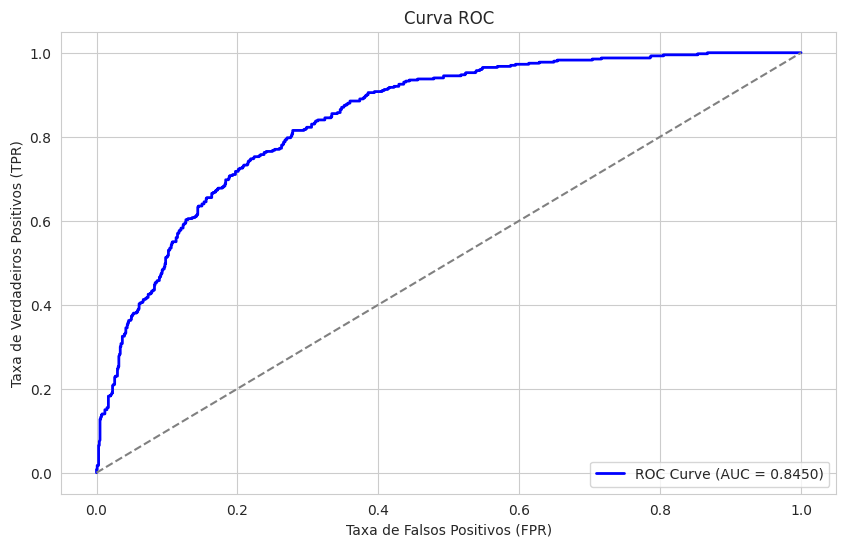

In [48]:
# Calculando a curva ROC e AUC (Area Under the Curve)
auc_score = roc_auc_score(result_test.Churn, result_test.Churn_Prob)
fpr, tpr, thresholds = roc_curve(result_test.Churn, result_test.Churn_Prob)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

In [49]:
import pickle # Salvando o modelo

with open("logm2.pkl", "wb") as f:
    pickle.dump(res, f)  # 'res' é o modelo ajustado (logm2.fit())